# Custom Model — ResNet18 + CBAM Adapters
CBAM (channel + spatial attention) adapters after each residual stage, with BatchNorm unfreezing and augmented training transforms.

In [1]:
import os

os.chdir("..")  
print(os.getcwd())

/Users/peter/Documents/MDS_UBC/DATA_586/food_classification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import ResNet18_Weights
from torch.utils.data import DataLoader
from torchvision.datasets import Food101

from helpers import (
    get_device, run_training, plot_results, count_trainable_params
)

## Architecture

In [3]:
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        mask = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * mask


class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
        )

    def forward(self, x):
        b, c, h, w = x.shape
        avg = torch.mean(x, dim=(2, 3))
        mx, _ = torch.max(x.view(b, c, -1), dim=2)
        attn = torch.sigmoid(self.mlp(avg) + self.mlp(mx)).view(b, c, 1, 1)
        return x * attn


class CBAMAdapter(nn.Module):
    """Bottleneck conv adapter + channel attention + spatial attention (residual)."""
    def __init__(self, channels: int, reduction_factor: int = 8):
        super().__init__()
        bottleneck = channels // reduction_factor
        self.conv_adapter = nn.Sequential(
            nn.Conv2d(channels, bottleneck, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(bottleneck, channels, kernel_size=1),
        )
        # initialise last conv as zero → identity at start of training
        nn.init.zeros_(self.conv_adapter[-1].weight)
        self.channel_attn = ChannelAttention(channels)
        self.spatial_attn = SpatialAttention()

    def forward(self, x):
        x = x + self.conv_adapter(x)
        x = x + self.channel_attn(x)
        x = x + self.spatial_attn(x)
        return x


class ResNetWithCBAMAdapters(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.model = backbone
        self.adapters = nn.ModuleDict({
            "layer1": CBAMAdapter(64),
            "layer2": CBAMAdapter(128),
            "layer3": CBAMAdapter(256),
            "layer4": CBAMAdapter(512),
        })

    def forward(self, x):
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)

        for stage in ("layer1", "layer2", "layer3", "layer4"):
            x = getattr(self.model, stage)(x)
            x = self.adapters[stage](x)

        x = self.model.avgpool(x)
        x = torch.flatten(x, 1)
        return self.model.fc(x)

## Data — augmented train transform, standard val transform

In [4]:
weights = ResNet18_Weights.DEFAULT
mean    = [0.485, 0.456, 0.406]
std     = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3),
    transforms.RandomRotation(15),
    transforms.RandomApply(
        [transforms.ColorJitter(brightness=0.3, contrast=0.3)], p=0.3
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),
    transforms.Normalize(mean=mean, std=std),
])
val_transform = weights.transforms()

train_dataset = Food101(root="data", split="train", download=True, transform=train_transform)
val_dataset   = Food101(root="data", split="test",  download=True, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False, num_workers=8, pin_memory=True)

## Model setup

In [5]:
backbone = models.resnet18(weights=weights)
model    = ResNetWithCBAMAdapters(backbone)

# Freeze backbone
for param in model.model.parameters():
    param.requires_grad = False

# Replace & unfreeze head
model.model.fc = nn.Linear(model.model.fc.in_features, 101)
for param in model.model.fc.parameters():
    param.requires_grad = True

# Unfreeze BatchNorm γ / β
for m in model.model.modules():
    if isinstance(m, nn.BatchNorm2d):
        for param in m.parameters():
            param.requires_grad = True

# Unfreeze adapters
for param in model.adapters.parameters():
    param.requires_grad = True

print(f"Trainable params: {count_trainable_params(model):,}")

# Per-group learning rates
bn_params = [
    p for m in model.model.modules()
    if isinstance(m, nn.BatchNorm2d)
    for p in m.parameters()
]
optimizer = optim.Adam([
    {"params": model.adapters.parameters(),  "lr": 1e-3},
    {"params": model.model.fc.parameters(),  "lr": 1e-3},
    {"params": bn_params,                    "lr": 1e-4},
])

Trainable params: 194,469


In [6]:
model, train_losses, val_losses, train_accs, val_accs = run_training(
    model=model,
    model_name="resnet18_custom_model",
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=10,
    optimizer=optimizer,       # pass the custom multi-group optimizer
)

[resnet18_custom_model] Final checkpoint found — loading metrics for plotting.


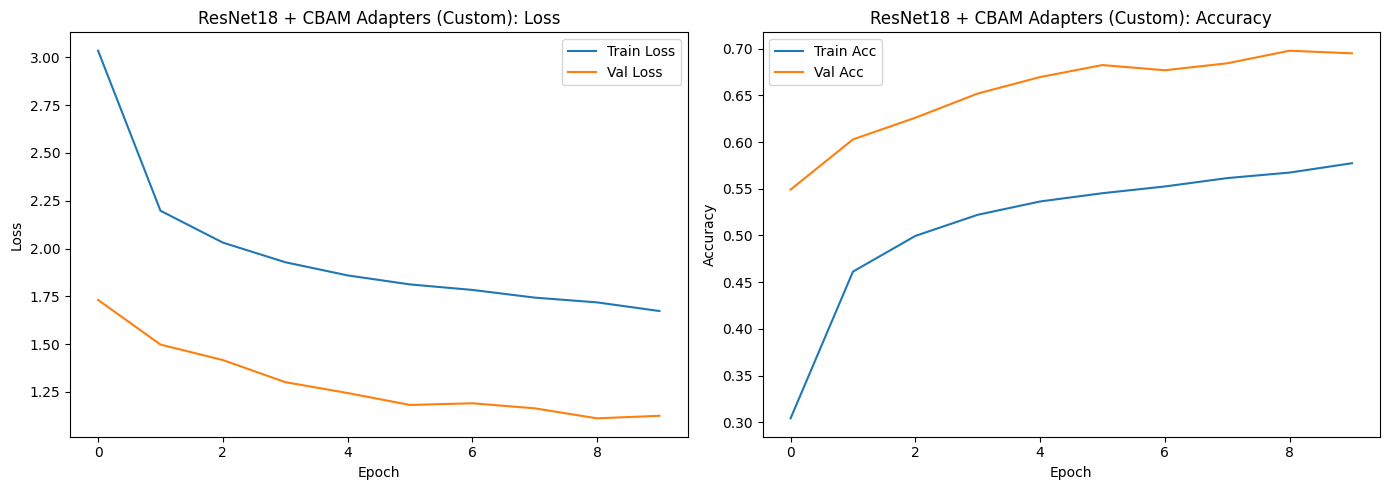

In [7]:
plot_results(train_losses, val_losses, train_accs, val_accs, "ResNet18 + CBAM Adapters (Custom)")